<h1><font color="#4472c4">MSBA 511: Data Mining for Business Analytics</font></h1>

## Programming Assignment 4: Ensembles

In this assignment, you will be working with a bank credit card dataset that includes a variety of customer demographic, relationship, and credit card usage variables. The customer retention department has noticed an increasing number of customers closing their credit card accounts. Customer attrition (or churn) is costly to the bank — lost revenue, lower customer lifetime value, and reduced brand loyalty.

The department is seeking your help to develop a data mining solution that can predict which customers are most likely to leave. With these predictions, the bank hopes to proactively reach out to at-risk customers with targeted offers or personalized service to improve retention.

⚠️ **Note**: This assignment is intentionally designed to be open-ended, allowing you to make your own modeling decisions and demonstrate creativity in your approach. General instructions are provided to guide your work but you have flexibility in how you choose to explore the data, engineer features, and build and evaluate predictive models. 

To ensure consistency across submission, sample output will only be provided for **Step 1** specifically for an example train/test split and the cost evaluation metric. This will ensure everyone is working with the same data partitions and calculating the evaluation metric appropriately.

### Bonus Opportunity

🏆 **Compete for Top Model Performance!**
To add a little friendly competition, **5** bonus points will be awarded for the top 5 model performers based on the estimated cost savings % generated by your best model on the test partition. 

#### Rules:

- Your notebook must clearly demonstrate that your model was tuned and evaluated using either:
  - **Cross-validation**, or  
  - A **validation partition** (subset of the training data)  
  *→ You cannot use the 30% test partition for tuning your model.*

- You may only use **one** or a combination of the **7 algorithms** listed in Step 2.  
  *→ No XGBoost, LightGBM, CatBoost, or any other algorithms not listed are allowed.*

- To be eligible, your model must meet **at least one** of the following conditions:
  - Use an **ensemble model** that combines multiple standalone learners  
  - Engineer **new features** in your training data  
  - Evaluate and adjust the **probability cutoff** in at least one of your **standalone meta-learners** or your **ensemble model**

#### Import libraries

Set `SEED = 23` for expected output reproducability.

⚠️ **Be sure to use the `SEED` variable for every `random_state` parameter across this entire assignment.**

In [1]:
# Set random seed
SEED = 23

In [29]:
# Write your import library statments below


## Step 1: Initial Data Load and Validation

**Load data from csv file and display first 5 rows.**

Perform the following preparation steps:

- Convert all columns to lower case
- Set the index of the data dataframe as the `clientnum` column
- Convert the `attrition_flag` column to a binary variable:
  - **Attrited Customer: 1**  
  - **Existing Customer: 0**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

,attrition_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
clientnum,,,,,,,,,,,,,,,,,,,,
768805383,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
818770008,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
713982108,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
769911858,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
709106358,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


**Create a 30% Test partition.**

⚠️ **Note**: you may choose to create train/validation/test partitions later in the assignment such as **AFTER** you prepare all of the features for modeling. However, this step will be used to validate that you are using the defined `SEED` for `random_state` for your train_test_split counts and values for the y dependent variable.

In the final step for this assignment, you **MUST** evaluate your final model on the test partition that is _30%_ of the original data. 

🚫 **Don't Touch the Test Set for Model Tuning!** 🚫

Your test data partition should only be used one time — at the very end — to evaluate your final, fully-trained model.

🔒 The test set is like a locked drawer. You should not look inside or use it to:

- Select features
- Tune hyperparameters
- Choose thresholds
- Compare model performance
- Make modeling decisions

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

Training Set: (7088, 19) Test Set: (3039, 19)


**Validate your counts in `y_train` and `y_test`.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

y_train counts:


attrition_flag
0    5951
1    1137
Name: count, dtype: int64

y_test counts:


attrition_flag
0    2549
1     490
Name: count, dtype: int64

**Create an Estimated Cost Reduction Custom Scorer.**

For this assignment, you will be evaluating your model performance based on an estimated cost reduction method. Assume the following costs:

- False Positive (FP): **\$150** average cost per customer for providing unnecessary retention offers and discounts
- False Negative (FN): **\$500** average cost per customer in lost credit card spend revenue

As seen in the above `y_test` counts, there are **490** attrited customers so 490 * \$500 = **\$245,000** in potential cost (lost revenue). However, we cannot provide offers to every existing customer as the cost of the unnecessary benefits will easily outweigh the customer retention benefits. The objective is to identify the model that optimizes the **Estimated cost reduction %** defined as:

$$1 - \frac{\text{pred\_cost}}{\text{true\_cost}}$$

In the numerator, `pred_cost` is your model performance using the average costs referenced above and `true_cost` is the number of true attrited customers in the partition * 500. For example, in the test partition, the `true_cost` is **\$245,000**

Since the number of records in the training/validation and test partitions will be different, this will ensure you are evaluating your models with a consistent metric where the goal is `greater_is_better`.

<h4 style="color:blue"> Write Your Code Below: </h4>

In [ ]:
# Write your custom function below

In [ ]:
# Fill-in the blanks below for your y_test data and custom scorer function
np.random.seed(SEED)  # for reproducibility
y_naive_preds = np.random.choice([0, 1], size=len(y_test))
print('----------------------------------------------------------------------------------------------------')
print('Confusion Matrix:')
print(confusion_matrix(____, y_naive_preds))
print('----------------------------------------------------------------------------------------------------')
print(f'Precision Score: {precision_score(____, y_naive_preds):.2%}')
print(f'Recall Score: {recall_score(____, y_naive_preds):.2%}')
# Write your print statement below for your custom prediction cost function using y_test and y_naive_preds
print(f'Estimated cost reduction % for the Naive random model is: {____(____, y_naive_preds):.2%}')
print('----------------------------------------------------------------------------------------------------')

<h3 style="color:teal"> Expected Output: </h3>

----------------------------------------------------------------------------------------------------
Confusion Matrix:
[[1261 1288]
 [ 242  248]]
----------------------------------------------------------------------------------------------------
Precision Score: 16.15%
Recall Score: 50.61%
Estimated cost reduction % for the Naive random model is: -28.24%
----------------------------------------------------------------------------------------------------


🎯 The random naive model was able to correctly identify about 50% of the customers who actually left (recall), but it significantly over-predicted attrition — with only 16% of its positive predictions being correct (precision).

Even worse, using this naive approach would cost the bank **\$314,200**, which is about 28.24% **MORE** than if the bank had done nothing at all to improve customer retention.

💡 Clearly, this is not an effective solution.💡

**Your challenge**:
Can you design a smarter, more accurate model that helps the bank identify at-risk customers — while reducing false alarms and minimizing cost?

## Step 2: Preprocessing and Modeling

Prepare the data and evaluate at least **5 different models** using cross-validation on the training data. You must choose classification algorithms that we covered in class/textbook:

- Decision Tree Classifier
- kNN
- Naive Bayes Classifer (you may use GaussianNB (not discussed in class) or MultinomialNB
- Logistic Regression
- Random Forest Classifier
- Bagging Classifier
- AdaBoost Classifier

Include a confusion matrix and the estimated cost reduction % for each model using **5 k-fold cross-validation.** A sample for a simple 2 split decision tree has been provided below.

🚀 Feature Engineering is how you can differentiate your models. Most models will use the same raw data — but how you transform or create new features can give you an edge. Things to Consider:

- Can you combine features to create new insights? (i.e., ratios instead of raw numeric variables)
- Are there flags or indicators you could create? (i.e., frequent user, high dollar spender)

🔑 Don't Just Accept the Default Threshold! Most classification models use a default probability cutoff of 0.5. That threshold might not be optimal for your problem — especially when the cost of false positives and false negatives are not equal.

- Are false positives really expensive? You might want a higher threshold.
- Are false negatives worse because attrition is costly? Lowering the threshold could catch more at-risk customers.
- Is your dataset imbalanced? The default 0.5 might favor the majority class.

ℹ️ **You can use as many code block cells below as needed. Just add new cells below the _Write Your Code Below_ and above the _Sample Output_ cells.** ℹ️

<h4 style="color:blue"> Write Your Code Below: </h4>

In [ ]:
# Model 1


In [ ]:
# Model 2


In [ ]:
# Model 3


In [ ]:
# Model 4


In [ ]:
# Model 5


<h3 style="color:teal"> Sample Output: </h3>

In [40]:
def plot_confusion_matrix(clf, X, y, ax, title):
    ConfusionMatrixDisplay.from_estimator(clf, X, y, cmap=plt.cm.Blues, colorbar=False, ax=ax)
    plt.title(title)
    plt.tight_layout()

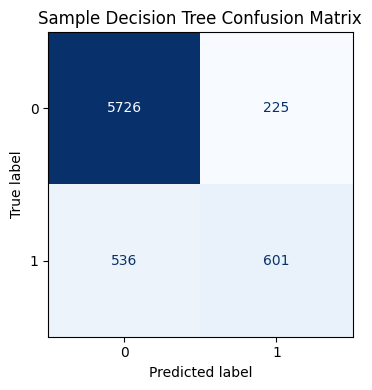

Estimated cost reduction % for the sample Decision Tree model is: 46.54%


## Step 3: Build an Ensemble Model

In this step, you will explore the power of ensemble learning — combining the predictions from multiple models to (hopefully) improve performance.

Several classifiers in sklearn, such as `AdaBoostClassifier`, `BaggingClassifier`, and `RandomForestClassifier`, are considered meta-learners and inherently ensemble methods. However, you will now build your own custom ensemble by combining the predictions from multiple different models created in **Step 2**.

Create at least **ONE** ensemble model that combines predictions from multiple individual models using either:

1. Majority Vote → Combine predicted class labels and select the most common prediction
2. Average Probabilities → Average the predicted probabilities and classify based on a threshold (ex: 0.5)
3. Meta-learner stacking

Using the classifications generated by the ensemble, display a confusion matrix and the estimated cost reduction % for each model using **5 k-fold cross-validation.**

You may create your own method to evaluate the predictions for the ensemble or use the sklearn `VotingClassifier` or `StackingClassifier`.

ℹ️ **You can use as many code block cells below as needed. Just add new cells above the No Expected Output cell.** ℹ️

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:red"> No Expected Output </h3>

### Step 3b: Analysis and Interpretation of Ensemble Performance

Reflect on the performance of your ensemble model compared to at least one of your individual models. Discuss the performance of your ensemble model and specifically address the following:

- Did your ensemble model improve performance compared to one of your individual models?
- If not, why do you think the ensemble did not perform better?
- What might this tell you about your models, the data, or the specific problem of predicting customer attrition?
- Would you recommend using the ensemble in practice? Why or why not?

<h4 style="color:purple"> Write Your Free-Form Response Below: </h4>

## Step 4: Final Model Evaluation 

Now that you’ve explored different models, tested an ensemble, and evaluated performance — it’s time to wrap up your analysis and make a final recommendation. Display your final model performance on the test data below.

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:red"> No Expected Output </h3>

**Write a brief summary discussing your final model selection.**

Be sure to address the following:

- Which model did you select as your final recommendation? Was it a single model or your ensemble model?
- Why did you choose this model over others?
- How did your final model perform? Include relevant evaluation metrics (Precision, Recall, Cost Reduction)

Discuss strengths and weaknesses of your final model’s performance.

- Would you recommend deploying this model in a real-world setting? What trade-offs should the business consider?
- What are possible risks or limitations of your model?

<h4 style="color:purple"> Write Your Free-Form Response Below: </h4>